# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Fill in before submitting:

Name of the Group: Group X

```
Student 1: 
Student 2: 
Student 3: 
Student 4: 
Student 5: 
```


## 0. Setup & Imports


In [6]:
# Install dependencies (run once)
# !pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

# Set project root
project_root = '/Users/marta/1NOVA/RL/RL_GroupAG/RL Project Code/sepsis_project - Students Version'
os.chdir(project_root)
sys.path.insert(0, project_root)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('/tmp/plots', exist_ok=True)
PLOTS_DIR = '/tmp/plots'

SEED = 42
np.random.seed(SEED)

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')

ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [7]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [8]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [9]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5983
  Survival rate  : 70.3%
  Mean ep length : 10.5 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


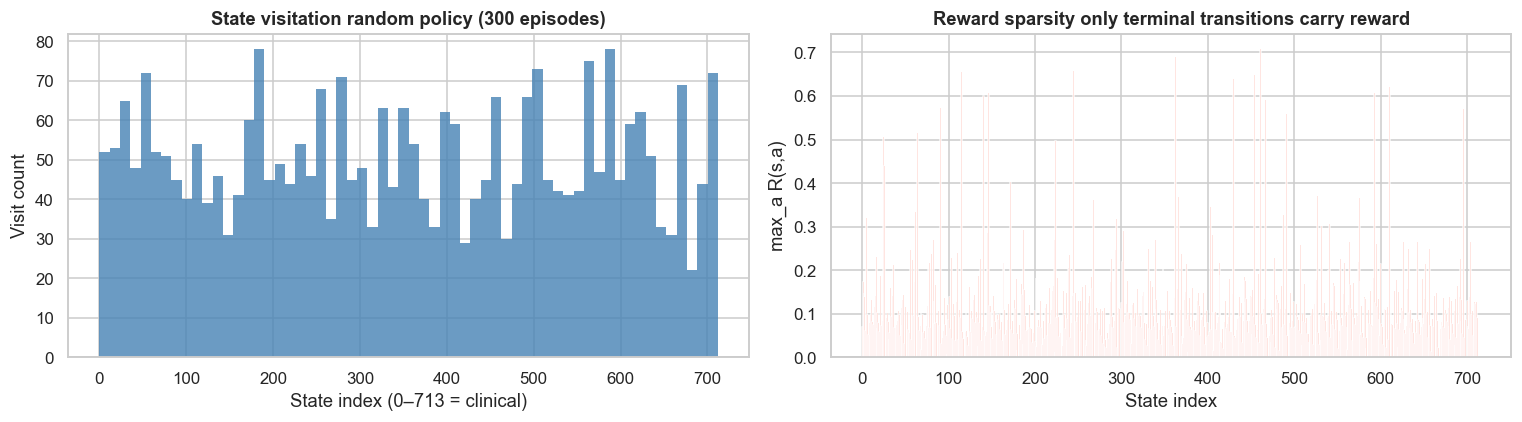

In [10]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [11]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [12]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5639
Overall survival rate : 65.8%



In [13]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv


## DQN imports

In [14]:
import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

## Device setup

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


##  Inspect the clinical environment dimensions

In [16]:
env = make_clinical_env()
obs, info = env.reset(seed=SEED)

state_dim = obs.shape[0]   # should be 47
n_actions = env.action_space.n  # should be 25

print(f"State dimension  : {state_dim}")
print(f"Number of actions: {n_actions}")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
State dimension  : 47
Number of actions: 25


## Replay Buffer

In [17]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

## The DQN neural network

In [18]:
class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.net(x)

## Hyparameters

In [19]:
GAMMA        = 0.99     # discount factor: how much future rewards matter
LR           = 1e-3     # learning rate for the optimizer
BATCH_SIZE   = 128      # how many experiences to sample per training step
BUFFER_SIZE  = 100_000  # max experiences stored in replay buffer

EPS_START    = 1.0      # start fully exploring (random actions)
EPS_END      = 0.05     # never go below 5% exploration
EPS_DECAY    = 0.995    # multiply epsilon by this each episode

TARGET_UPDATE = 10      # copy policy_net → target_net every N episodes

N_EPISODES   = 2000     # total training episodes
MAX_STEPS    = 200      # max steps per episode before truncation

## Initialize networks, optimizer, buffer

In [20]:
policy_net = DQN(state_dim, n_actions).to(device)
target_net = DQN(state_dim, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer     = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

print("Networks initialized.")
print(f"Policy net parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

Networks initialized.
Policy net parameters: 114,201


## Action selection function

In [21]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()   # explore: random treatment
    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = policy_net(state_t)
    return q_values.argmax(dim=1).item()   # exploit: best known treatment

## Training step function

In [22]:
def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return None   # not enough memories yet, skip

    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    states      = torch.FloatTensor(states).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones       = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # What the network currently predicts for these (state, action) pairs
    current_q = policy_net(states).gather(1, actions)

    # What the target should be: immediate reward + discounted future value
    with torch.no_grad():
        next_q   = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()

    return loss.item()

## Training loop

In [23]:
episode_rewards = []
episode_losses  = []
epsilon         = EPS_START

for episode in range(N_EPISODES):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0
    losses = []

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        loss = train_step()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward
        if done:
            break

    # Decay exploration
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # Sync target network periodically
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else 0)

    if (episode + 1) % 100 == 0:
        recent_survival = np.mean(np.array(episode_rewards[-100:]) > 0) * 100
        print(f"Episode {episode+1:4d} | "
              f"Survival (last 100): {recent_survival:.1f}% | "
              f"Epsilon: {epsilon:.3f} | "
              f"Loss: {episode_losses[-1]:.5f}")

print("\nTraining finished.")
env.close()

Episode  100 | Survival (last 100): 73.0% | Epsilon: 0.606 | Loss: 0.03499
Episode  200 | Survival (last 100): 75.0% | Epsilon: 0.367 | Loss: 0.86750
Episode  300 | Survival (last 100): 65.0% | Epsilon: 0.222 | Loss: 6.40660
Episode  400 | Survival (last 100): 73.0% | Epsilon: 0.135 | Loss: 37.71063
Episode  500 | Survival (last 100): 63.0% | Epsilon: 0.082 | Loss: 132.60682
Episode  600 | Survival (last 100): 65.0% | Epsilon: 0.050 | Loss: 325.71279
Episode  700 | Survival (last 100): 70.0% | Epsilon: 0.050 | Loss: 809.68808
Episode  800 | Survival (last 100): 65.0% | Epsilon: 0.050 | Loss: 1331.57416
Episode  900 | Survival (last 100): 62.0% | Epsilon: 0.050 | Loss: 2627.89355
Episode 1000 | Survival (last 100): 70.0% | Epsilon: 0.050 | Loss: 2891.01733
Episode 1100 | Survival (last 100): 66.0% | Epsilon: 0.050 | Loss: 3267.45329
Episode 1200 | Survival (last 100): 70.0% | Epsilon: 0.050 | Loss: 4230.82600
Episode 1300 | Survival (last 100): 68.0% | Epsilon: 0.050 | Loss: 4228.34823


## Plot learning curves

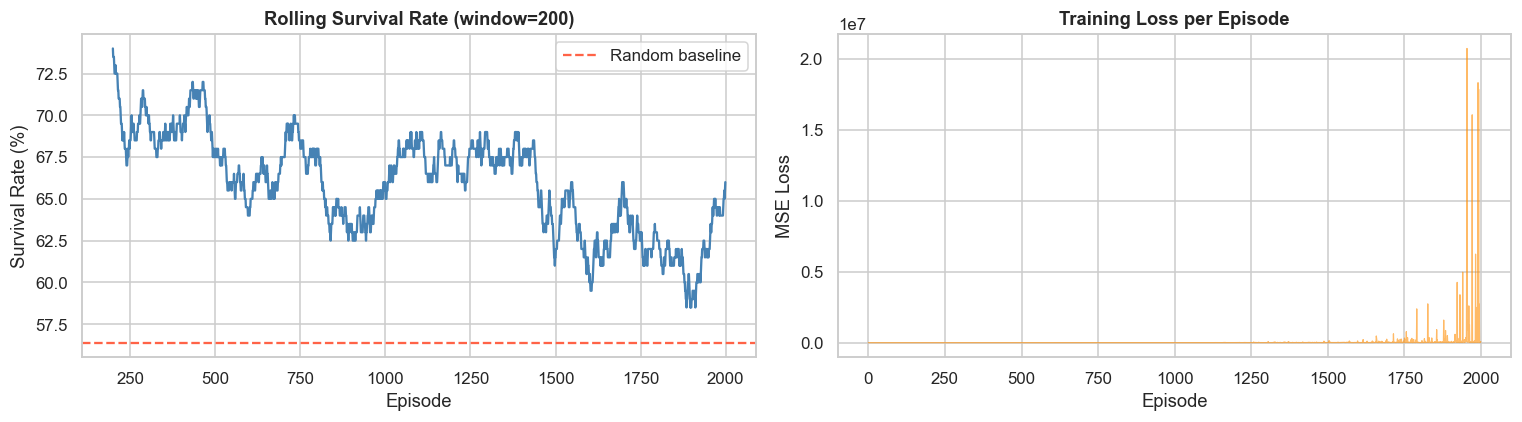

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Survival rolling average
rewards_arr = np.array(episode_rewards)
rolling_survival = pd.Series((rewards_arr > 0).astype(float)).rolling(200).mean() * 100

axes[0].plot(rolling_survival, color='steelblue', linewidth=1.5)
axes[0].axhline(y=clinical_rand_mean * 100, color='tomato', linestyle='--', label='Random baseline')
axes[0].set_title('Rolling Survival Rate (window=200)', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].legend()

# Loss curve
axes[1].plot(episode_losses, color='darkorange', alpha=0.6, linewidth=0.8)
axes[1].set_title('Training Loss per Episode', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_dqn_training.png', bbox_inches='tight')
plt.show()

## Evaluation function

In [25]:
def evaluate_dqn(model, n_episodes=500, seed=SEED + 9999):
    model.eval()
    env_eval = make_clinical_env()

    returns, lengths = [], []
    noisy_r, clean_r, missing_r, nomiss_r = [], [], [], []
    acute_count = 0

    for ep in range(n_episodes):
        state, info = env_eval.reset(seed=seed + ep)
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False
        total_r, steps, done = 0.0, 0, False

        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                action = model(state_t).argmax(dim=1).item()
            state, r, te, tr, info = env_eval.step(action)
            total_r += r
            steps += 1
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        returns.append(total_r)
        lengths.append(steps)
        if ep_noisy:   noisy_r.append(total_r)
        else:          clean_r.append(total_r)
        if ep_missing: missing_r.append(total_r)
        else:          nomiss_r.append(total_r)
        if ep_acute:   acute_count += 1

    env_eval.close()
    model.train()

    print("===== DQN Evaluation (500 episodes) =====")
    print(f"Overall survival rate : {np.mean(np.array(returns) > 0)*100:.1f}%")
    print(f"Mean return           : {np.mean(returns):.4f}")
    print(f"Mean episode length   : {np.mean(lengths):.1f} steps")
    print()
    print(f"Clean episodes        : {np.mean(np.array(clean_r) > 0)*100:.1f}% survival  (n={len(clean_r)})")
    print(f"Noisy episodes        : {np.mean(np.array(noisy_r) > 0)*100:.1f}% survival  (n={len(noisy_r)})")
    print(f"No-missing episodes   : {np.mean(np.array(nomiss_r) > 0)*100:.1f}% survival  (n={len(nomiss_r)})")
    print(f"Missing-obs episodes  : {np.mean(np.array(missing_r) > 0)*100:.1f}% survival  (n={len(missing_r)})")
    print(f"Acute event episodes  : {acute_count} out of {n_episodes} (irreducible losses)")

evaluate_dqn(policy_net)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
===== DQN Evaluation (500 episodes) =====
Overall survival rate : 63.2%
Mean return           : 0.5305
Mean episode length   : 9.9 steps

Clean episodes        : 61.0% survival  (n=428)
Noisy episodes        : 76.4% survival  (n=72)
No-missing episodes   : 63.4% survival  (n=413)
Missing-obs episodes  : 62.1% survival  (n=87)
Acute event episodes  : 44 out of 500 (irreducible losses)


In [27]:
# Adjusted survival rate excluding unwinnable acute event episodes
acute_count = 44       # from the evaluation output above
total_eval  = 500
overall_survival = 0.632  # from the evaluation output above

controllable = total_eval - acute_count
adjusted = (total_eval * overall_survival) / controllable
print(f"Total episodes        : {total_eval}")
print(f"Acute event episodes  : {acute_count} (irreducible — no algorithm can prevent these)")
print(f"Controllable episodes : {controllable}")
print(f"Adjusted survival rate: {adjusted*100:.1f}%  (excluding acute events)")

Total episodes        : 500
Acute event episodes  : 44 (irreducible — no algorithm can prevent these)
Controllable episodes : 456
Adjusted survival rate: 69.3%  (excluding acute events)


## Final summary table

In [26]:
summary = pd.DataFrame({
    "Method"         : ["Random Baseline (Config B)", "DQN (Config B)"],
    "Survival Rate"  : [
        f"{clinical_rand_mean * 100:.1f}%",
        f"{np.mean(np.array(episode_rewards[-500:]) > 0)*100:.1f}%"
    ],
    "Mean Return"    : [
        f"{clinical_rand_mean:.4f}",
        f"{np.mean(episode_rewards[-500:]):.4f}"
    ],
})
print(summary.to_string(index=False))

                    Method Survival Rate Mean Return
Random Baseline (Config B)         56.4%      0.5639
            DQN (Config B)         64.2%      0.5314


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


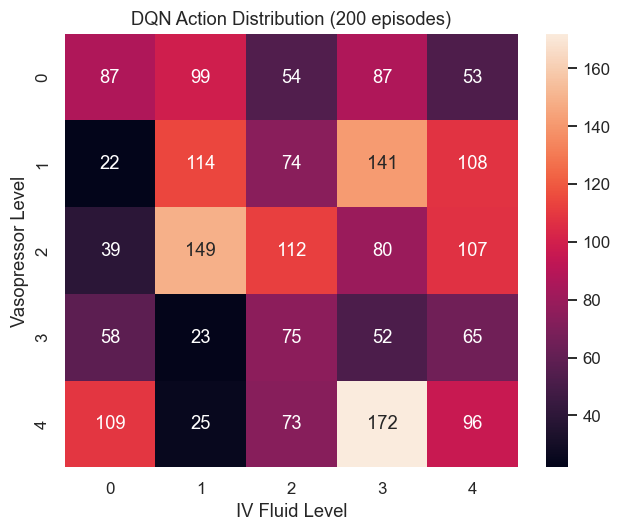

In [28]:
# Action distribution heatmap
action_counts = np.zeros((5, 5))
eval_env = make_clinical_env()
for ep in range(200):
    state, _ = eval_env.reset(seed=SEED + 2000 + ep)
    done = False
    while not done:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            action = policy_net(state_t).argmax(dim=1).item()
        action_counts[action // 5, action % 5] += 1
        state, _, te, tr, _ = eval_env.step(action)
        done = te or tr
eval_env.close()

plt.figure(figsize=(6, 5))
sns.heatmap(action_counts, annot=True, fmt='g',
            xticklabels=['0','1','2','3','4'],
            yticklabels=['0','1','2','3','4'])
plt.xlabel('IV Fluid Level')
plt.ylabel('Vasopressor Level')
plt.title('DQN Action Distribution (200 episodes)')
plt.tight_layout()
plt.show()

In [29]:
# Hyperparameter sensitivity analysis
configs = [
    {"name": "Default",          "lr": 1e-3,  "gamma": 0.99, "eps_decay": 0.995, "batch": 128},
    {"name": "Lower LR",         "lr": 5e-4,  "gamma": 0.99, "eps_decay": 0.995, "batch": 128},
    {"name": "Slower Decay",     "lr": 1e-3,  "gamma": 0.99, "eps_decay": 0.999, "batch": 128},
    {"name": "Smaller Batch",    "lr": 1e-3,  "gamma": 0.99, "eps_decay": 0.995, "batch": 64},
    {"name": "Lower Gamma",      "lr": 1e-3,  "gamma": 0.95, "eps_decay": 0.995, "batch": 128},
]

hp_results = []

for cfg in configs:
    # Fresh networks
    p_net = DQN(state_dim, n_actions).to(device)
    t_net = DQN(state_dim, n_actions).to(device)
    t_net.load_state_dict(p_net.state_dict())
    t_net.eval()
    opt = optim.Adam(p_net.parameters(), lr=cfg["lr"])
    buf = ReplayBuffer(100_000)
    eps = 1.0

    hp_env = make_clinical_env()
    ep_rewards = []

    for episode in range(1000):  # shorter run for comparison
        state, _ = hp_env.reset(seed=SEED + episode)
        total_r, done = 0.0, False

        for _ in range(MAX_STEPS):
            if random.random() < eps:
                action = hp_env.action_space.sample()
            else:
                st = torch.FloatTensor(state).unsqueeze(0).to(device)
                with torch.no_grad():
                    action = p_net(st).argmax(dim=1).item()

            next_state, r, te, tr, _ = hp_env.step(action)
            done = te or tr
            buf.push(state, action, r, next_state, done)

            if len(buf) >= cfg["batch"]:
                states_b, actions_b, rewards_b, next_states_b, dones_b = buf.sample(cfg["batch"])
                sb = torch.FloatTensor(states_b).to(device)
                ab = torch.LongTensor(actions_b).unsqueeze(1).to(device)
                rb = torch.FloatTensor(rewards_b).unsqueeze(1).to(device)
                nsb = torch.FloatTensor(next_states_b).to(device)
                db = torch.FloatTensor(dones_b).unsqueeze(1).to(device)
                cq = p_net(sb).gather(1, ab)
                with torch.no_grad():
                    tq = rb + cfg["gamma"] * t_net(nsb).max(1, keepdim=True)[0] * (1 - db)
                loss = nn.MSELoss()(cq, tq)
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(p_net.parameters(), 1.0)
                opt.step()

            state = next_state
            total_r += r
            if done:
                break

        eps = max(0.05, eps * cfg["eps_decay"])
        if episode % 10 == 0:
            t_net.load_state_dict(p_net.state_dict())
        ep_rewards.append(total_r)

    hp_env.close()

    survival = np.mean(np.array(ep_rewards[-200:]) > 0) * 100
    hp_results.append({"Config": cfg["name"], "Survival (last 200 ep)": f"{survival:.1f}%",
                        "LR": cfg["lr"], "Gamma": cfg["gamma"],
                        "Eps Decay": cfg["eps_decay"], "Batch": cfg["batch"]})
    print(f"{cfg['name']:20s} → {survival:.1f}% survival")

df_hp = pd.DataFrame(hp_results)
print()
print(df_hp.to_string(index=False))

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Default              → 65.5% survival
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Lower LR             → 67.0% survival
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Slower Decay         → 64.0% survival
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Smaller Batch        → 66.0% survival
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Lower Gamma          → 66.5% survival

       Config Survival (last 200 ep)     LR  Gamma  Eps Decay  Batch
      Default                  65.5% 0.0010   0.99      0.995    128
     Lower LR                  67.0% 0.0005   0.99      0.995    128
 Slower Decay                  64.0% 0.0010   0.99  

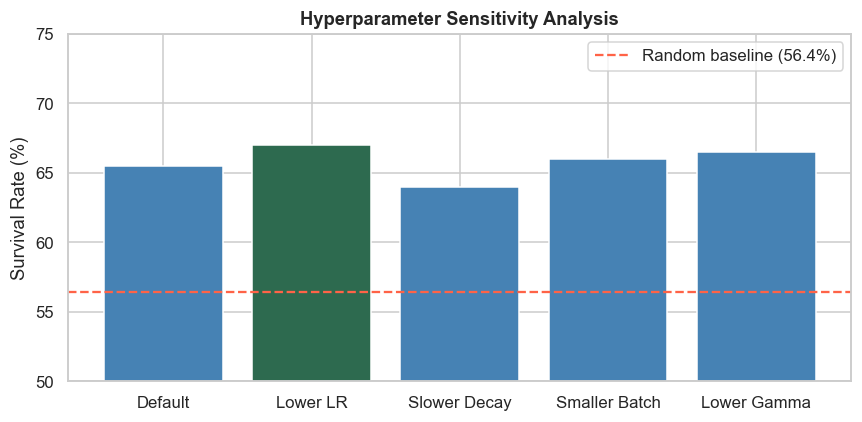

In [30]:
names = [r["Config"] for r in hp_results]
survivals = [float(r["Survival (last 200 ep)"].replace("%","")) for r in hp_results]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, survivals, color=['steelblue' if s < max(survivals) else '#2d6a4f' for s in survivals])
plt.axhline(y=56.4, color='tomato', linestyle='--', label='Random baseline (56.4%)')
plt.ylabel('Survival Rate (%)')
plt.title('Hyperparameter Sensitivity Analysis', fontweight='bold')
plt.ylim(50, 75)
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_hp_sensitivity.png', bbox_inches='tight')
plt.show()

In [31]:
GAMMA        = 0.99
LR           = 5e-4     # <-- changed from 1e-3 to 5e-4 (best from sensitivity analysis)
BATCH_SIZE   = 128
BUFFER_SIZE  = 100_000

EPS_START    = 1.0
EPS_END      = 0.05
EPS_DECAY    = 0.995

TARGET_UPDATE = 10

N_EPISODES   = 2000
MAX_STEPS    = 200

In [32]:
# Reset everything so we start clean
policy_net = DQN(state_dim, n_actions).to(device)
target_net = DQN(state_dim, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer     = optim.Adam(policy_net.parameters(), lr=LR)
replay_buffer = ReplayBuffer(BUFFER_SIZE)

print("Networks re-initialized with best hyperparameters.")
print(f"LR = {LR} | GAMMA = {GAMMA} | EPS_DECAY = {EPS_DECAY} | BATCH = {BATCH_SIZE}")

Networks re-initialized with best hyperparameters.
LR = 0.0005 | GAMMA = 0.99 | EPS_DECAY = 0.995 | BATCH = 128


In [33]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()   # explore: random treatment
    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = policy_net(state_t)
    return q_values.argmax(dim=1).item()   # exploit: best known treatment

In [34]:
def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return None   # not enough memories yet, skip

    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

    states      = torch.FloatTensor(states).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones       = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # What the network currently predicts for these (state, action) pairs
    current_q = policy_net(states).gather(1, actions)

    # What the target should be: immediate reward + discounted future value
    with torch.no_grad():
        next_q   = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = nn.MSELoss()(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()

    return loss.item()

In [35]:
episode_rewards = []
episode_losses  = []
epsilon         = EPS_START

for episode in range(N_EPISODES):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0
    losses = []

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        loss = train_step()
        if loss is not None:
            losses.append(loss)

        state = next_state
        total_reward += reward
        if done:
            break

    # Decay exploration
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # Sync target network periodically
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else 0)

    if (episode + 1) % 100 == 0:
        recent_survival = np.mean(np.array(episode_rewards[-100:]) > 0) * 100
        print(f"Episode {episode+1:4d} | "
              f"Survival (last 100): {recent_survival:.1f}% | "
              f"Epsilon: {epsilon:.3f} | "
              f"Loss: {episode_losses[-1]:.5f}")

print("\nTraining finished.")
env.close()

Episode  100 | Survival (last 100): 66.0% | Epsilon: 0.606 | Loss: 0.01216
Episode  200 | Survival (last 100): 82.0% | Epsilon: 0.367 | Loss: 0.28822
Episode  300 | Survival (last 100): 66.0% | Epsilon: 0.222 | Loss: 2.81703
Episode  400 | Survival (last 100): 69.0% | Epsilon: 0.135 | Loss: 24.85295
Episode  500 | Survival (last 100): 67.0% | Epsilon: 0.082 | Loss: 64.31947
Episode  600 | Survival (last 100): 58.0% | Epsilon: 0.050 | Loss: 115.12860
Episode  700 | Survival (last 100): 64.0% | Epsilon: 0.050 | Loss: 214.43741
Episode  800 | Survival (last 100): 68.0% | Epsilon: 0.050 | Loss: 436.36726
Episode  900 | Survival (last 100): 61.0% | Epsilon: 0.050 | Loss: 469.81720
Episode 1000 | Survival (last 100): 69.0% | Epsilon: 0.050 | Loss: 592.63345
Episode 1100 | Survival (last 100): 69.0% | Epsilon: 0.050 | Loss: 597.75433
Episode 1200 | Survival (last 100): 72.0% | Epsilon: 0.050 | Loss: 743.32961
Episode 1300 | Survival (last 100): 65.0% | Epsilon: 0.050 | Loss: 707.28506
Episode

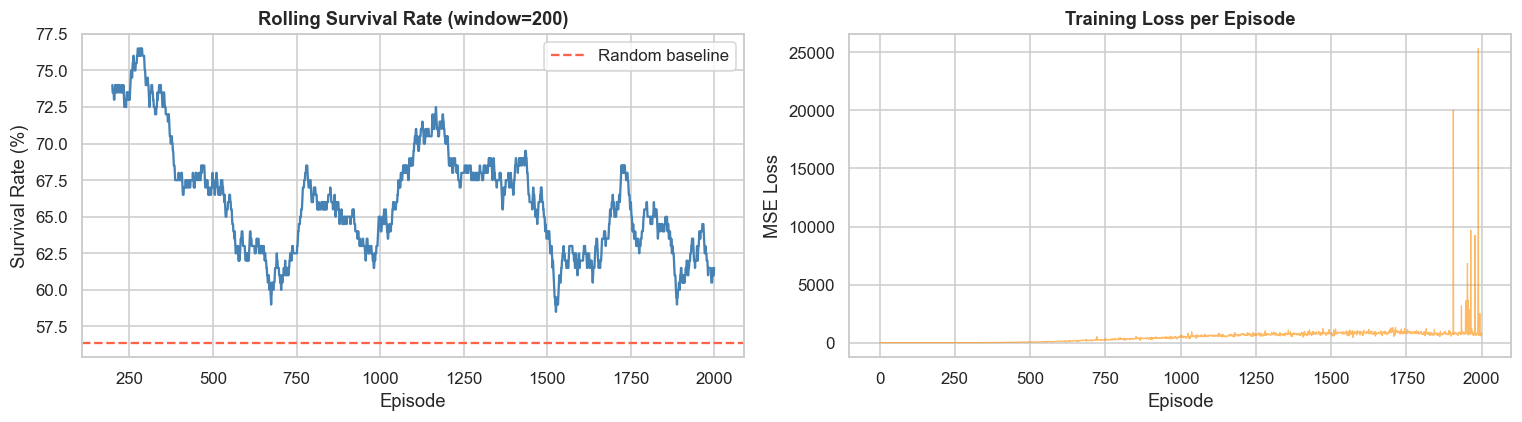

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Survival rolling average
rewards_arr = np.array(episode_rewards)
rolling_survival = pd.Series((rewards_arr > 0).astype(float)).rolling(200).mean() * 100

axes[0].plot(rolling_survival, color='steelblue', linewidth=1.5)
axes[0].axhline(y=clinical_rand_mean * 100, color='tomato', linestyle='--', label='Random baseline')
axes[0].set_title('Rolling Survival Rate (window=200)', fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].legend()

# Loss curve
axes[1].plot(episode_losses, color='darkorange', alpha=0.6, linewidth=0.8)
axes[1].set_title('Training Loss per Episode', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_dqn_training.png', bbox_inches='tight')
plt.show()

In [37]:
def evaluate_dqn(model, n_episodes=500, seed=SEED + 9999):
    model.eval()
    env_eval = make_clinical_env()

    returns, lengths = [], []
    noisy_r, clean_r, missing_r, nomiss_r = [], [], [], []
    acute_count = 0

    for ep in range(n_episodes):
        state, info = env_eval.reset(seed=seed + ep)
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False
        total_r, steps, done = 0.0, 0, False

        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                action = model(state_t).argmax(dim=1).item()
            state, r, te, tr, info = env_eval.step(action)
            total_r += r
            steps += 1
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        returns.append(total_r)
        lengths.append(steps)
        if ep_noisy:   noisy_r.append(total_r)
        else:          clean_r.append(total_r)
        if ep_missing: missing_r.append(total_r)
        else:          nomiss_r.append(total_r)
        if ep_acute:   acute_count += 1

    env_eval.close()
    model.train()

    print("===== DQN Evaluation (500 episodes) =====")
    print(f"Overall survival rate : {np.mean(np.array(returns) > 0)*100:.1f}%")
    print(f"Mean return           : {np.mean(returns):.4f}")
    print(f"Mean episode length   : {np.mean(lengths):.1f} steps")
    print()
    print(f"Clean episodes        : {np.mean(np.array(clean_r) > 0)*100:.1f}% survival  (n={len(clean_r)})")
    print(f"Noisy episodes        : {np.mean(np.array(noisy_r) > 0)*100:.1f}% survival  (n={len(noisy_r)})")
    print(f"No-missing episodes   : {np.mean(np.array(nomiss_r) > 0)*100:.1f}% survival  (n={len(nomiss_r)})")
    print(f"Missing-obs episodes  : {np.mean(np.array(missing_r) > 0)*100:.1f}% survival  (n={len(missing_r)})")
    print(f"Acute event episodes  : {acute_count} out of {n_episodes} (irreducible losses)")

evaluate_dqn(policy_net)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
===== DQN Evaluation (500 episodes) =====
Overall survival rate : 64.2%
Mean return           : 0.5444
Mean episode length   : 9.8 steps

Clean episodes        : 63.8% survival  (n=439)
Noisy episodes        : 67.2% survival  (n=61)
No-missing episodes   : 63.7% survival  (n=422)
Missing-obs episodes  : 66.7% survival  (n=78)
Acute event episodes  : 41 out of 500 (irreducible losses)


In [38]:
summary = pd.DataFrame({
    "Method"         : ["Random Baseline (Config B)", "DQN (Config B)"],
    "Survival Rate"  : [
        f"{clinical_rand_mean * 100:.1f}%",
        f"{np.mean(np.array(episode_rewards[-500:]) > 0)*100:.1f}%"
    ],
    "Mean Return"    : [
        f"{clinical_rand_mean:.4f}",
        f"{np.mean(episode_rewards[-500:]):.4f}"
    ],
})
print(summary.to_string(index=False))

                    Method Survival Rate Mean Return
Random Baseline (Config B)         56.4%      0.5639
            DQN (Config B)         63.8%      0.5391


In [39]:
acute_count = 41
total_eval  = 500
overall_survival = 0.642

controllable = total_eval - acute_count
adjusted = (total_eval * overall_survival) / controllable
print(f"Total episodes        : {total_eval}")
print(f"Acute event episodes  : {acute_count} (irreducible — no algorithm can prevent these)")
print(f"Controllable episodes : {controllable}")
print(f"Adjusted survival rate: {adjusted*100:.1f}%  (excluding acute events)")

Total episodes        : 500
Acute event episodes  : 41 (irreducible — no algorithm can prevent these)
Controllable episodes : 459
Adjusted survival rate: 69.9%  (excluding acute events)
